## Feature Engineering

5. Engineer at least 8 features from the main table: 
   - CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL 
   - ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL 
   - CREDIT_TERM = AMT_ANNUITY / AMT_CREDIT (proxy for loan term) 
   - DAYS_EMPLOYED_RATIO = DAYS_EMPLOYED / DAYS_BIRTH 
   - INCOME_PER_PERSON = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS 
   - EXT_SOURCE_MEAN = mean of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - EXT_SOURCE_STD = std of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - AGE_BUCKET = pd.cut(age, bins=[20,30,40,50,60,70,100]) 
6. Engineer at least 4 aggregation features from bureau.csv: 
   - Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE 
   - Re-run correlation analysis, engineered features should have higher correlation than original features to TARGET
   - Test for multicollinearity, drop features that have r>0.95
7. Encode categorical variables: ordinal for NAME_EDUCATION_TYPE (ordered), one-hot for others 
with <10 categories. Drop high-cardinality categoricals (>50 categories) or use frequency encoding. 
8. Save the final preprocessed DataFrame to data/preprocessed_train.csv.

### Load data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

In [2]:
clean_train_path = Path(f"{os.getcwd()}/../data/application_train_cleaned.csv")
df = pd.read_csv(clean_train_path)

In [3]:
display(df.head())
display(df.info())
display(df.describe())

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
0,71,100083,0,Cash loans,M,Y,Y,0,103500.0,573628.5,...,3.0,0,0,0,0,0,0,0,0,0
1,124,100145,0,Cash loans,F,Y,Y,1,202500.0,260725.5,...,3.0,0,0,0,0,0,0,0,0,0
2,143,100165,0,Cash loans,F,Y,Y,0,175500.0,1293502.5,...,2.0,1,1,0,0,0,0,0,0,0
3,152,100179,0,Cash loans,F,Y,N,0,202500.0,675000.0,...,4.0,0,0,0,0,0,0,0,0,0
4,161,100190,0,Cash loans,M,Y,N,0,162000.0,263686.5,...,3.0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12968 entries, 0 to 12967
Columns: 132 entries, Unnamed: 0 to missingness_AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(50), object(16)
memory usage: 13.1+ MB


None

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
count,12968.000000,12968.000000,12968.000000,12968.000000,1.296800e+04,1.296800e+04,12968.000000,1.296800e+04,12968.000000,12968.000000,...,11702.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000
mean,153995.736814,278458.833359,0.060302,0.570481,2.199984e+05,7.023502e+05,31764.294147,6.366832e+05,0.024367,-14421.510487,...,1.750555,0.053131,0.212060,0.153146,0.097625,0.097625,0.097625,0.097625,0.097625,0.097625
std,88976.658150,103028.854790,0.238055,0.763939,1.411020e+05,4.678843e+05,17039.997690,4.331356e+05,0.017097,3570.484520,...,1.778737,0.224303,0.408783,0.360142,0.296818,0.296818,0.296818,0.296818,0.296818,0.296818
min,71.000000,100083.000000,0.000000,0.000000,2.816100e+04,4.500000e+04,2317.500000,4.500000e+04,0.000290,-25018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76133.500000,188292.500000,0.000000,0.000000,1.350000e+05,3.150000e+05,19614.375000,2.700000e+05,0.010643,-16728.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,153912.500000,278379.000000,0.000000,0.000000,1.800000e+05,5.850000e+05,29250.000000,4.950000e+05,0.020246,-13977.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,232029.500000,368754.000000,0.000000,1.000000,2.700000e+05,9.611460e+05,40546.125000,9.000000e+05,0.031329,-11632.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,307482.000000,456226.000000,1.000000,5.000000,4.500000e+06,4.050000e+06,225000.000000,4.050000e+06,0.072508,-7695.000000,...,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 5. Engineer 8 new features

In [4]:
engineered_features = []
def engineer_basic_features(dataframe, enged_features):

    # first re-add age column
    dataframe['age'] = abs(dataframe['DAYS_BIRTH'] / 365)

    # credit income ratio
    dataframe['CREDIT_INCOME_RATIO'] = dataframe['AMT_CREDIT'] / dataframe['AMT_INCOME_TOTAL']

    # annuity income ratio
    dataframe['ANNUITY_INCOME_RATIO'] = dataframe['AMT_ANNUITY'] / dataframe['AMT_INCOME_TOTAL']

    # credit term
    dataframe['CREDIT_TERM'] = dataframe['AMT_ANNUITY'] / dataframe['AMT_CREDIT']

    # days employed ratio, but first, impute sentinel to avoid NaN values being produced from division
    dataframe['DAYS_EMPLOYED'] = dataframe['DAYS_EMPLOYED'].replace(np.nan, dataframe['DAYS_EMPLOYED'].median())
    dataframe['DAYS_EMPLOYED_RATIO'] = dataframe['DAYS_EMPLOYED'] / dataframe['DAYS_BIRTH']

    # income per person
    dataframe['INCOME_PER_PERSON'] = dataframe['AMT_INCOME_TOTAL'] / dataframe['CNT_FAM_MEMBERS']

    # ext source mean
    dataframe['EXT_SOURCE_MEAN'] = dataframe[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

    # ext source standard deviation
    dataframe['EXT_SOURCE_STD'] = dataframe[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

    # age bucket/bins
    dataframe['AGE_BUCKET'] = pd.cut(dataframe['age'], bins=[20,30,40,50,60,70,100])

    enged_features += ['age', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'AGE_BUCKET']
    return dataframe

df = engineer_basic_features(df, engineered_features)

### 6. Engineer aggregation features (Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE)

In [5]:
# read in bureau dataset
bureau_path = Path(f"{os.getcwd()}/../data/bureau.csv")
bureau_df = pd.read_csv(bureau_path)

Since we want the number of active credit loans for each customer, it does not suffice to simply count the number of entries for CREDIT_ACTIVE, since this is a categorical column indicating whether that credit loan is open/closed. We'll convert this to binary column then sum up the Trues/the 1s

Now, we'll join back to the original dataframe to enrich the dataset with the aggregated features at the customer level. We use a left join since we want to retain all customers, then we'll deal with the nulls accordingly later

Now, the join introduces some new nulls to the dataset after having engineered features. Let's deal with these as follows
- For count features, NaN means that there is no count, or that the count is 0, e.g. BUREAU_COUNT = 0 means that there were 0 bureau records
- For max features, a max of NaN aligns with a max of 0, e.g. nonexistnet max of amount of credit overdue essentially means 0
- For mean features, we'll use the median, since it won't be easily affected by extreme values

In [6]:
def engineer_aggregate_features(dataframe, enged_features):
    bureau_df["CREDIT_IS_ACTIVE"] = (bureau_df["CREDIT_ACTIVE"] == "Active").astype(int)
    agg_features = bureau_df.groupby(by=['SK_ID_CURR']).agg(
        bureau_records=('SK_ID_BUREAU', 'count'),
        num_active_credits=('CREDIT_IS_ACTIVE', 'sum'),
        mean_days_credit=('DAYS_CREDIT', 'mean'),
        max_credit_sum_overdue=('AMT_CREDIT_SUM_OVERDUE', 'max')).reset_index()
    # join back to original df
    dataframe = dataframe.merge(agg_features, how='left', on='SK_ID_CURR')
    dataframe["bureau_records"] = dataframe["bureau_records"].fillna(0)
    dataframe["num_active_credits"] = dataframe["num_active_credits"].fillna(0)
    dataframe["max_credit_sum_overdue"] = dataframe["max_credit_sum_overdue"].fillna(0)
    dataframe["mean_days_credit"] = dataframe["mean_days_credit"].fillna(dataframe["mean_days_credit"].median())
    enged_features += ['bureau_records', 'num_active_credits', 'mean_days_credit', 'max_credit_sum_overdue']
    return dataframe

df = engineer_aggregate_features(df, engineered_features)

### 7. Encode categorical variables

First we'll drop categorical features that have high cardinality (>50\%) -- this is just noise

Next, we'll encode the `NAME_EDUCATION_TYPE` using ordinal encoding

Now, we'll do one-hot encoding on the columns that remain

In [7]:
def encode_categorical_features(dataframe, enged_features):
    # first find all high cardinality variables
    display(dataframe.select_dtypes(include=['object', 'category']).nunique().sort_values(ascending=False))
    categorical_cols = dataframe.select_dtypes(include=['object', 'category']).nunique().sort_values(ascending=False).index
    enged_features += ['NAME_EDUCATION_TYPE']
    # define mapping for education
    education_mapping = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5 }
    dataframe['NAME_EDUCATION_TYPE'] = dataframe['NAME_EDUCATION_TYPE'].map(education_mapping)
    one_hot_encoded = pd.get_dummies(dataframe[categorical_cols], dtype=int)
    dataframe = pd.concat([dataframe, one_hot_encoded], axis=1).drop(columns=categorical_cols)
    return dataframe

df = encode_categorical_features(df, engineered_features)

ORGANIZATION_TYPE             57
OCCUPATION_TYPE               18
WALLSMATERIAL_MODE             7
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
NAME_HOUSING_TYPE              6
NAME_FAMILY_STATUS             5
AGE_BUCKET                     5
NAME_EDUCATION_TYPE            5
NAME_INCOME_TYPE               5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   1
dtype: int64

### Re-run correlation analysis

In [8]:
fts = df.drop(columns=['TARGET'])
target_correlation = fts.corrwith(df['TARGET'], numeric_only=True).sort_values(ascending=False).head(30)
display(target_correlation)

mean_days_credit                           0.068032
REGION_RATING_CLIENT_W_CITY                0.063431
EXT_SOURCE_STD                             0.060833
DAYS_EMPLOYED                              0.055156
REGION_RATING_CLIENT                       0.054966
FLAG_DOCUMENT_3                            0.053968
num_active_credits                         0.052266
DAYS_BIRTH                                 0.049022
NAME_INCOME_TYPE_Working                   0.046422
NAME_CONTRACT_TYPE_Cash loans              0.045560
AGE_BUCKET_(20, 30]                        0.044470
ANNUITY_INCOME_RATIO                       0.044355
OWN_CAR_AGE                                0.041118
CODE_GENDER_M                              0.036896
ORGANIZATION_TYPE_Self-employed            0.036479
OCCUPATION_TYPE_Laborers                   0.036199
NAME_INCOME_TYPE_Unemployed                0.034666
AMT_REQ_CREDIT_BUREAU_YEAR                 0.033901
DAYS_ID_PUBLISH                            0.032631
NAME_HOUSING

From the above output our newly engineered variables are among some of the highest correlated features with the target. A Pearson correlation of $|r|<0.1$> is not immediate cause for concern as financial datasets come with a lot of nonlinearity and interaction effects

### Testing for multicollinearity

<Axes: >

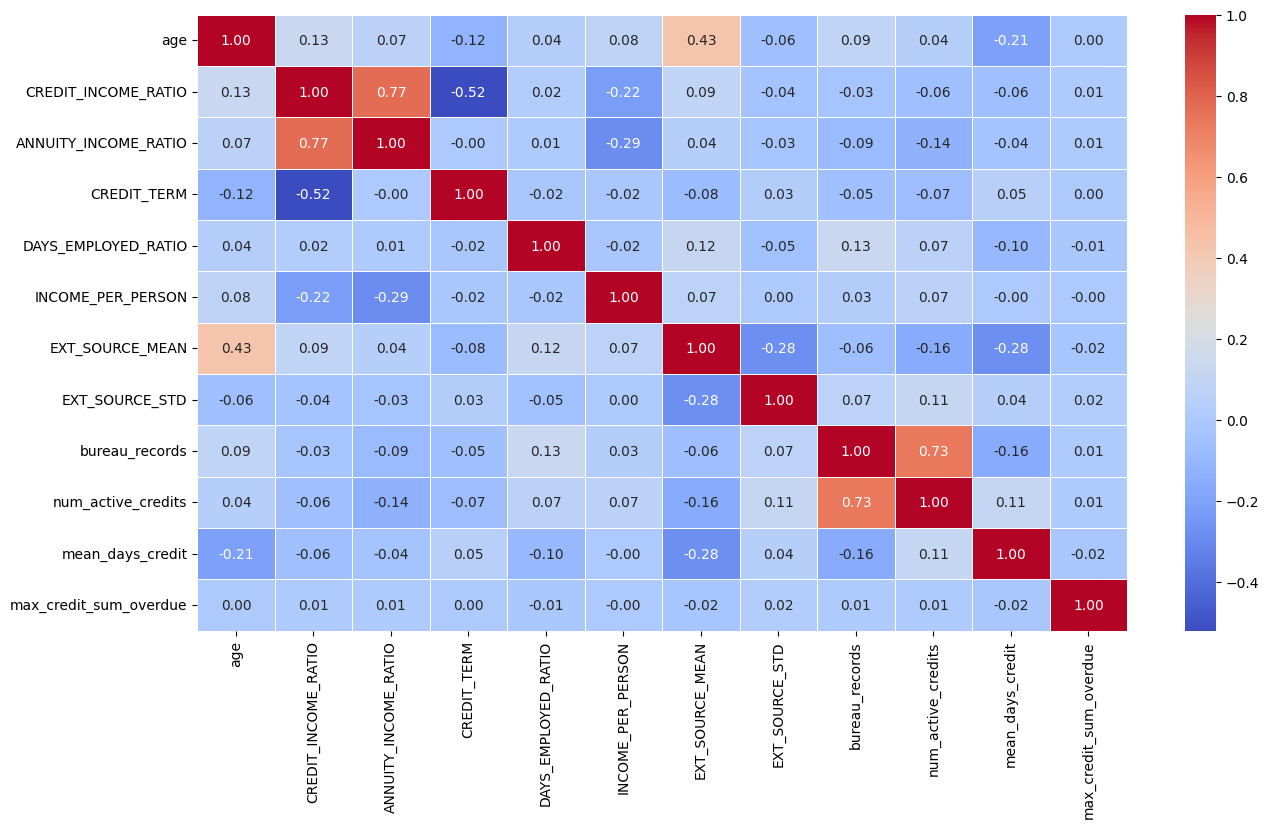

In [9]:
engineered_features.remove('AGE_BUCKET')
engineered_features.remove('NAME_EDUCATION_TYPE')
engineered_features_df = df[engineered_features]
corr_matrix = engineered_features_df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt
# plot heatmap
plt.figure(figsize=(15,8))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [10]:
display(df.isna().sum()[df.isna().sum() > 0])
has_nulls = df.isna().sum()[df.isna().sum() > 0].index

EXT_SOURCE_3                  1986
AMT_REQ_CREDIT_BUREAU_HOUR    1266
AMT_REQ_CREDIT_BUREAU_DAY     1266
AMT_REQ_CREDIT_BUREAU_WEEK    1266
AMT_REQ_CREDIT_BUREAU_MON     1266
AMT_REQ_CREDIT_BUREAU_QRT     1266
AMT_REQ_CREDIT_BUREAU_YEAR    1266
dtype: int64

We still have some nulls to take care of, since using models on null values usually doesn't go well. We first get the columns that still have nulls. The `AMT_REQ` features have missingness indicators, but let's still impute, the missingness indicators are a signal to the model that data was originally missing. Same with `EXT_SOURCE_3`

In [11]:
df[has_nulls] = df[has_nulls].fillna(df[has_nulls].median())

In [12]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

### Save preprocessed dataframe

In [13]:
preprocessed_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df.to_csv(preprocessed_path, index=False)

## Unsupervised Learning (K-Means Clustering)

Objective: Segment Home Credit applicants into clusters and analyze whether different segments have different default rates. This enriches your credit model with behavioral insights

In [26]:
clustering_df = pd.read_csv(preprocessed_path)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# import kmeans
from sklearn.cluster import KMeans

# plotting
import matplotlib.pyplot as plt

### Select numerical features for clustering and normalize using StandardScaler

This puts all the features on the same scale, which is essential because we are using Euclidean distance. Not having features on the same scale would severely distort the distance

In [28]:
features_to_cluster = ['age', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD']
clustering_data = clustering_df[features_to_cluster]

scaler = StandardScaler()
# normalize the data
normalized_data = scaler.fit_transform(clustering_data)

### Run k-Means with k=2 to k=8. Plot the elbow curve (inertia vs. k) and silhouette score vs. k. Choose the optimal k

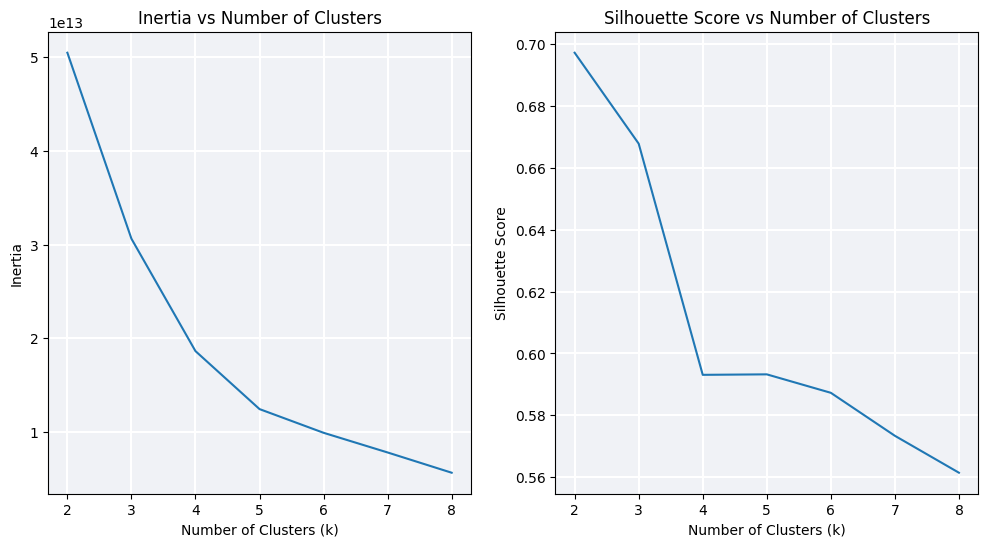

In [ ]:
k_clusters = range(2,9)
inertia = []
silhouettes = []

for k in k_clusters:
    # initialize a separate model for each k
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(clustering_data)

    inertia.append(kmeans.inertia_)
    score = silhouette_score(clustering_data, labels)
    silhouettes.append(score)

# plot inertia and silhouette score
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax1, ax2 = axes
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Inertia vs Number of Clusters')
ax1.grid(
    visible=True,       
    which='major',      
    axis='both',        
    color='white',      
    linestyle='-',      
    linewidth=1.5,      
    alpha=1.0           
)
ax1.set_facecolor('#f0f2f6')
ax1.plot(k_clusters, inertia)

ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(
    visible=True,       
    which='major',     
    axis='both',        
    color='white',      
    linestyle='-',      
    linewidth=1.5,      
    alpha=1.0           
)
ax2.set_facecolor("#f0f2f6")
ax2.plot(k_clusters, silhouettes)

Based on the above plots, it seems that the "elbow" point of the inertia group is at $k=4$ 

### Fit with optimal $k$, and add cluster label as feature to application dataset

In [30]:
best_k_means = KMeans(n_clusters=4, random_state=42)

# assign customer segments as a feature
clustering_df['customer_segment'] = best_k_means.fit_predict(normalized_data)
display(clustering_df.head())

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,customer_segment
0,71,100083,0,0,103500.0,573628.5,24435.0,463500.0,0.009657,-15406,...,0,0,0,1,1,0,1,0,1,1
1,124,100145,0,1,202500.0,260725.5,16789.5,198000.0,0.018850,-16282,...,0,0,0,1,1,0,1,0,1,3
2,143,100165,0,0,175500.0,1293502.5,35568.0,1129500.0,0.018850,-21961,...,0,0,0,1,1,0,1,0,1,1
3,152,100179,0,0,202500.0,675000.0,53329.5,675000.0,0.031329,-11375,...,0,0,1,0,1,0,1,0,1,0
4,161,100190,0,0,162000.0,263686.5,24781.5,238500.0,0.022625,-13972,...,0,0,1,0,1,0,1,0,1,0


### Profile each cluster: compute mean of key features and default rate per cluster. Give each cluster a descriptive business name

In [31]:
# multiple aggregation

cluster_aggregation = clustering_df.groupby(by=['customer_segment'])[features_to_cluster + ['TARGET']].agg('mean')
cluster_aggregation

,age,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,DAYS_EMPLOYED_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_STD,TARGET
customer_segment,,,,,,,,,
0,37.964051,1.778684,0.167844,0.096949,0.154076,103448.197778,0.523472,0.153349,0.050864
1,41.586522,7.382626,0.276865,0.039316,0.157580,71078.588787,0.542904,0.149652,0.064246
2,33.620846,2.807383,0.131218,0.049802,0.123925,106312.276054,0.416844,0.197832,0.097712
3,45.331291,2.962553,0.125162,0.045386,0.178585,145372.986845,0.614622,0.117989,0.022375


To be able to profile our clusters, we need to first understand what each of the averages shown above mean:
- age: average age
- CREDIT_INCOME_RATIO: average ratio of loan credit amount to total income of client
- ANNUITY_INCOME_RATIO: average ratio of the loan instalment amount to total income of client
- CREDIT_TERM: average duration of loan until being paid off
- DAYS_EMPLOYED_RATIO: average ratio of days employed to days since birth
- INCOME_PER_PERSON: average income per person of household of applicant
- EXT_SOURCE_MEAN: average of mean of normalized score from three external sources
- EXT_SOURCE_STD: average of standard deviation of normalized score from three external sources
- TARGET: default rate per cluster

Based on the above information, here are the profiles for each cluster:
- Cluster 0: Average borrowers with moderate income and moderate credit risk (5\% default rate, middle of the ground income per person, lowest ratio of credit to income, moderate instalment amount)
- Cluster 1: Highly leveraged borrowers carrying the largest debt burden relative to income, but with reasonably good historical credit quality (lowest income per person, highest ratio of credit to income, highest ratio of instalment to income)
- Cluster 2: Younger applicants with weaker external credit profiles and the highest observed default rate, representing the riskiest customer segment (moderate credit to income ratio, lowest ratio of employment days to days since birth)
- Cluster 3: Older, higher-income applicants with strong external credit scores and the lowest default rate, representing the safest customer segment (extremely low default rate, highest income per person, lowest ratio of instalment to income)

### Testing whether clustering improves best model from notebook 4

In [32]:
# load model
import joblib
model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")

with open(model_path, mode='rb') as f:
    best_model = joblib.load(f)

In [33]:
# one-hot encoding
customer_segments_one_hot = pd.get_dummies(data=clustering_df['customer_segment'])
clustering_df = pd.concat([clustering_df, customer_segments_one_hot], axis=1).drop(columns=['customer_segment'])

In [34]:
clustering_df.head()

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,0,1,2,3
0,71,100083,0,0,103500.0,573628.5,24435.0,463500.0,0.009657,-15406,...,1,1,0,1,0,1,False,True,False,False
1,124,100145,0,1,202500.0,260725.5,16789.5,198000.0,0.018850,-16282,...,1,1,0,1,0,1,False,False,False,True
2,143,100165,0,0,175500.0,1293502.5,35568.0,1129500.0,0.018850,-21961,...,1,1,0,1,0,1,False,True,False,False
3,152,100179,0,0,202500.0,675000.0,53329.5,675000.0,0.031329,-11375,...,0,1,0,1,0,1,True,False,False,False
4,161,100190,0,0,162000.0,263686.5,24781.5,238500.0,0.022625,-13972,...,0,1,0,1,0,1,True,False,False,False


In [35]:
# rename columns for better readability
clustering_df = clustering_df.rename(columns={0: 'Segment_0', 1: 'Segment_1', 2: 'Segment_2', 3: 'Segment_3'})

In [36]:
segment_columns = [f"Segment_{k}" for k in range(4)]

clustering_df[segment_columns] = clustering_df[segment_columns].astype(int)

In [37]:
# re-run training and evaluation
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

X, y = clustering_df.drop(columns=['TARGET']), clustering_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

y_pred_proba = best_model.fit(X_train, y_train).predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_pred_proba)

print(f"AUROC with customer segmentation is: {auroc :4f}")

AUROC with customer segmentation is: 0.752251


The AUROC from our best model was 0.743805, so the customer segmentation has helped the model improve its performance slightly, although whether the customer segmentation was worthwhile is debatable